# Direct temporal TFRecord preprocessing

This notebook is a clean, streaming replacement for `Pre_process_data.ipynb`.
It reads windows directly from the source GeoTIFFs and writes fixed-length
temporal examples to train and validation TFRecords. It does **not** create
`divided`, `final`, or per-patch `.npz` folders.

Every record has four ordered frames:

```text
[history 1, history 2, TARGET, future]
                       index 2
```

Unavailable frames are zero-filled and marked in `temporal_mask`. The target
year comes from the source folder/mask name and is stored explicitly, so it is
never inferred from the last valid frame.

The split is geographic: nearby patch centers are assigned to one spatial
block, and each block belongs exclusively to train or validation. All cloudy,
non-cloudy, SR, and non-SR versions of a location therefore remain in the same
split.

## Pipeline outline

1. Discover target-location folders and their Sentinel variants.
2. Build a target-centered four-frame sequence for every folder.
3. Audit source dimensions, alignment, years, and masks.
4. Preview deterministic geographic train/validation assignments.
5. Read 224×224 windows directly from the rasters.
6. Serialize each patch immediately to the appropriate TFRecord.
7. Validate schema, temporal ordering, class values, and split isolation.

The expensive export is guarded by `RUN_EXPORT`. Run the inventory and preview
cells first, inspect their output, then enable the export.

In [1]:
import hashlib
import json
import math
import os
import re
import struct
import time
import warnings
from collections import Counter, defaultdict
from contextlib import ExitStack, contextmanager
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import tensorflow as tf
from PIL import Image
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window

# These masks are trusted local rasters and can exceed Pillow's warning limit.
Image.MAX_IMAGE_PIXELS = None

# TensorFlow is used only for TFRecord serialization/parsing. Preserve GPU RAM
# for PyTorch training notebooks.
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError:
    pass

print("TensorFlow:", tf.__version__)
print("Rasterio:", rasterio.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.10.1
Rasterio: 1.4.4
NumPy: 1.26.4


## Configuration

The defaults point to the current source collection and create new output
files. Existing TFRecords are protected unless `OVERWRITE_OUTPUTS=True`.

`SPATIAL_BLOCK_DEGREES=0.05` groups neighboring patch centers into blocks of
roughly 5 km at these latitudes. This is stricter than checking exact
coordinates and reduces spatial leakage from immediately adjacent patches.

In [2]:
SOURCE_ROOT = Path(
    r"Y:\SPOT\2023\Asare\ssm_temporal\segmentation\original"
)
REAL_ROOT = SOURCE_ROOT / "real"
MASK_ROOT = SOURCE_ROOT / "mask"

OUTPUT_ROOT = Path(r"D:\Data\ssm_temporal")
TRAIN_TFRECORD = OUTPUT_ROOT / "ssm_footprint_train_clean.tfrecord"
VAL_TFRECORD = OUTPUT_ROOT / "ssm_footprint_val_clean.tfrecord"
SUMMARY_JSON = OUTPUT_ROOT / "ssm_footprint_clean_summary.json"

PATCH_SIZE = 224
STRIDE = 224
BAND_INDEXES = (1, 2, 3, 4, 5, 6)  # Rasterio uses one-based indexes.
TIMESTEPS = 4
TARGET_INDEX = 2
DAY_OF_YEAR = 1

VAL_FRACTION = 0.20
SPLIT_SEED = 42
SPATIAL_BLOCK_DEGREES = 0.05

# Source mask classes 1 and 2 are foreground class 1; source class 3 becomes 2.
CLASS_REMAP = {0: 0, 1: 1, 2: 1, 3: 2}
SCHEMA_VERSION = "prithvi-temporal-v2"

INCLUDE_EDGE_PATCHES = True
SKIP_INVALID_TARGET_PATCHES = True
OVERWRITE_OUTPUTS = False
RUN_EXPORT = False

# Useful for development. Leave both as None for a complete export.
MAX_GROUPS = None
MAX_PATCHES_PER_GROUP = None
PROGRESS_EVERY = 500

PREVIEW_TARGET_YEAR = 2021
PREVIEW_VARIANT = "harmonized"
PREVIEW_FOREGROUND = True
RANDOM_PREVIEW_SAMPLES = 6
RANDOM_TFRECORD_SAMPLES_PER_SPLIT = 3
RANDOM_PREVIEW_SEED = None  # None gives fresh samples on every run.

assert SOURCE_ROOT.exists(), SOURCE_ROOT
assert REAL_ROOT.exists(), REAL_ROOT
assert MASK_ROOT.exists(), MASK_ROOT
assert TIMESTEPS == 4 and TARGET_INDEX == 2

print("Source:", SOURCE_ROOT)
print("Train output:", TRAIN_TFRECORD)
print("Validation output:", VAL_TFRECORD)
print("RUN_EXPORT:", RUN_EXPORT)

Source: Y:\SPOT\2023\Asare\ssm_temporal\segmentation\original
Train output: D:\Data\ssm_temporal\ssm_footprint_train_clean.tfrecord
Validation output: D:\Data\ssm_temporal\ssm_footprint_val_clean.tfrecord
RUN_EXPORT: False


## Naming and sequence discovery

The folder prefix identifies the mask target year. Variant suffixes encode the
image product and cloud condition. Two nearest available historical years and
one nearest future year are selected. Missing slots remain `None`, which later
become zero tensors with `temporal_mask=0`.

Files whose spatial identifier does not match the folder are ignored and
reported. This catches the known mixed-content SR folder without silently
adding data from another location.

In [3]:
VARIANTS = (
    "sr_harmonized_cloudy",
    "sr_harmonized",
    "harmonized_cloudy",
    "harmonized",
)


def split_variant(name):
    """Return (base_without_variant, variant), preferring longest suffix."""
    for variant in VARIANTS:
        suffix = f"_{variant}"
        if name.endswith(suffix):
            return name[: -len(suffix)], variant
    raise ValueError(f"Unknown Sentinel variant: {name}")


def year_from_name(name):
    match = re.match(r"sentinel_(\d{4})-", name)
    if not match:
        raise ValueError(f"Cannot parse year from {name}")
    return int(match.group(1))


def spatial_id_from_name(name):
    base, _ = split_variant(Path(name).stem)
    return re.sub(r"^sentinel_\d{4}-", "", base)


@dataclass(frozen=True)
class SequencePlan:
    target_group: str
    folder: Path
    mask_path: Path
    variant: str
    target_year: int
    spatial_id: str
    frame_years: tuple
    frame_paths: tuple
    ignored_files: tuple

    @property
    def temporal_mask(self):
        return tuple(int(path is not None) for path in self.frame_paths)


def build_sequence_plan(folder, mask_root=MASK_ROOT):
    base, variant = split_variant(folder.name)
    target_year = year_from_name(base)
    spatial_id = re.sub(r"^sentinel_\d{4}-", "", base)
    mask_path = mask_root / f"{folder.name}.png"

    by_year = {}
    ignored = []
    for path in sorted(folder.glob("*.tif")):
        try:
            _, file_variant = split_variant(path.stem)
            file_spatial_id = spatial_id_from_name(path.name)
            file_year = year_from_name(path.name)
        except ValueError:
            ignored.append(path)
            continue

        if file_variant != variant or file_spatial_id != spatial_id:
            ignored.append(path)
            continue
        if file_year in by_year:
            raise ValueError(f"Duplicate year {file_year} in {folder}")
        by_year[file_year] = path

    if target_year not in by_year:
        raise FileNotFoundError(
            f"Target-year image {target_year} missing from {folder}"
        )
    if not mask_path.exists():
        raise FileNotFoundError(mask_path)

    history = sorted(year for year in by_year if year < target_year)[-2:]
    history = [None] * (2 - len(history)) + history
    future = sorted(year for year in by_year if year > target_year)
    future = future[0] if future else None
    frame_years = tuple(history + [target_year, future])
    frame_paths = tuple(
        by_year.get(year) if year is not None else None
        for year in frame_years
    )

    assert len(frame_paths) == TIMESTEPS
    assert frame_paths[TARGET_INDEX] is not None
    return SequencePlan(
        target_group=base,
        folder=folder,
        mask_path=mask_path,
        variant=variant,
        target_year=target_year,
        spatial_id=spatial_id,
        frame_years=frame_years,
        frame_paths=frame_paths,
        ignored_files=tuple(ignored),
    )


def discover_sequence_plans(real_root=REAL_ROOT):
    plans = [
        build_sequence_plan(folder)
        for folder in sorted(real_root.iterdir())
        if folder.is_dir()
    ]
    if not plans:
        raise RuntimeError(f"No sequence folders found under {real_root}")
    return plans


plans = discover_sequence_plans()
print(f"Discovered {len(plans)} sequence variants.")

Discovered 24 sequence variants.


In [4]:
inventory_rows = []
for plan in plans:
    inventory_rows.append(
        {
            "target_group": plan.target_group,
            "target_year": plan.target_year,
            "variant": plan.variant,
            "frame_years": [year or 0 for year in plan.frame_years],
            "file_level_temporal_mask": plan.temporal_mask,
            "ignored_tifs": len(plan.ignored_files),
            "mask": plan.mask_path.name,
        }
    )

inventory = pd.DataFrame(inventory_rows)
display(inventory)

print("\nVariants:")
print(inventory.groupby("variant").size().sort_index())
print("\nTarget years:")
print(inventory.groupby("target_year").size().sort_index())

for plan in plans:
    if plan.ignored_files:
        print(f"\nWARNING: ignored files in {plan.folder.name}")
        for path in plan.ignored_files:
            print("  ", path.name)

,target_group,target_year,variant,frame_years,file_level_temporal_mask,ignored_tifs,mask
0,sentinel_2015-0000011776-0000023552,2015,harmonized,"[0, 0, 2015, 2016]","(0, 0, 1, 1)",0,sentinel_2015-0000011776-0000023552_harmonized...
1,sentinel_2015-0000011776-0000023552,2015,harmonized_cloudy,"[0, 0, 2015, 2016]","(0, 0, 1, 1)",0,sentinel_2015-0000011776-0000023552_harmonized...
2,sentinel_2017-0000035328-0000023552,2017,harmonized,"[2015, 2016, 2017, 2018]","(1, 1, 1, 1)",0,sentinel_2017-0000035328-0000023552_harmonized...
3,sentinel_2017-0000035328-0000023552,2017,harmonized_cloudy,"[2015, 2016, 2017, 2018]","(1, 1, 1, 1)",0,sentinel_2017-0000035328-0000023552_harmonized...
4,sentinel_2018-0000047104-0000035328,2018,harmonized,"[2016, 2017, 2018, 2019]","(1, 1, 1, 1)",0,sentinel_2018-0000047104-0000035328_harmonized...
5,sentinel_2018-0000047104-0000035328,2018,harmonized_cloudy,"[2016, 2017, 2018, 2019]","(1, 1, 1, 1)",0,sentinel_2018-0000047104-0000035328_harmonized...
6,sentinel_2018-0000047104-0000035328,2018,sr_harmonized,"[0, 0, 2018, 2019]","(0, 0, 1, 1)",0,sentinel_2018-0000047104-0000035328_sr_harmoni...
7,sentinel_2018-0000047104-0000035328,2018,sr_harmonized_cloudy,"[0, 0, 2018, 2019]","(0, 0, 1, 1)",0,sentinel_2018-0000047104-0000035328_sr_harmoni...
8,sentinel_2021-0000023552-0000023552,2021,harmonized,"[2019, 2020, 2021, 2022]","(1, 1, 1, 1)",0,sentinel_2021-0000023552-0000023552_harmonized...
9,sentinel_2021-0000023552-0000023552,2021,harmonized_cloudy,"[2019, 2020, 2021, 2022]","(1, 1, 1, 1)",0,sentinel_2021-0000023552-0000023552_harmonized...



Variants:
variant
harmonized              7
harmonized_cloudy       7
sr_harmonized           5
sr_harmonized_cloudy    5
dtype: int64

Target years:
target_year
2015    2
2017    2
2018    4
2021    4
2022    4
2024    8
dtype: int64


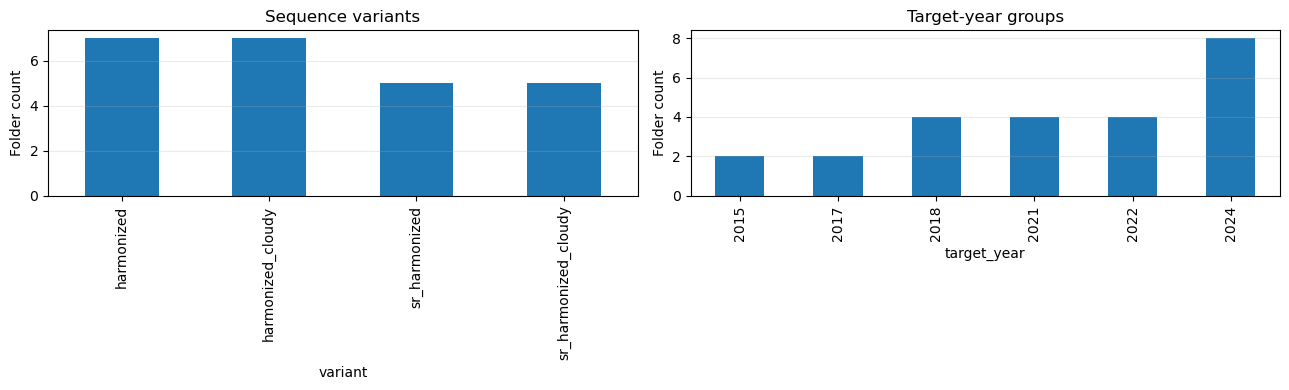

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4))
inventory["variant"].value_counts().sort_index().plot.bar(
    ax=axes[0], title="Sequence variants"
)
inventory["target_year"].value_counts().sort_index().plot.bar(
    ax=axes[1], title="Target-year groups"
)
axes[0].set_ylabel("Folder count")
axes[1].set_ylabel("Folder count")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Source audit

This audit checks target/mask dimensions, band count, CRS, transform alignment,
and missing frames. Misaligned yearly rasters are allowed: extraction uses a
`WarpedVRT` to match the target grid. Masks must already match the target pixel
grid because PNG masks do not carry georeferencing.

In [6]:
def same_grid(source, target):
    return (
        source.width == target.width
        and source.height == target.height
        and source.crs == target.crs
        and source.transform.almost_equals(target.transform)
    )


def audit_plan(plan):
    issues = []
    with rasterio.open(plan.frame_paths[TARGET_INDEX]) as target:
        target_shape = (target.height, target.width)
        if target.count < len(BAND_INDEXES):
            issues.append(f"target has only {target.count} bands")
        if target.crs is None:
            issues.append("target CRS is missing")

        with Image.open(plan.mask_path) as mask:
            mask_shape = (mask.height, mask.width)
        if mask_shape != target_shape:
            issues.append(
                f"mask {mask_shape} != target raster {target_shape}"
            )

        aligned = 0
        reprojected = 0
        for path in plan.frame_paths:
            if path is None:
                continue
            with rasterio.open(path) as source:
                if source.count < len(BAND_INDEXES):
                    issues.append(f"{path.name} has {source.count} bands")
                if same_grid(source, target):
                    aligned += 1
                else:
                    reprojected += 1

    return {
        "target_group": plan.target_group,
        "variant": plan.variant,
        "target_year": plan.target_year,
        "target_shape": target_shape,
        "frame_years": [year or 0 for year in plan.frame_years],
        "file_mask": plan.temporal_mask,
        "aligned_frames": aligned,
        "reprojected_frames": reprojected,
        "ignored_files": len(plan.ignored_files),
        "issues": issues,
    }


audit = pd.DataFrame([audit_plan(plan) for plan in plans])
display(audit)

all_issues = [
    (row["target_group"], row["variant"], issue)
    for row in audit.to_dict("records")
    for issue in row["issues"]
]
if all_issues:
    print("AUDIT ISSUES:")
    for issue in all_issues:
        print("  ", issue)
else:
    print("All target/mask dimensions and band requirements passed.")

print("Frames requiring on-the-fly alignment:", audit["reprojected_frames"].sum())
print("Ignored/misfiled TIFFs:", audit["ignored_files"].sum())

,target_group,variant,target_year,target_shape,frame_years,file_mask,aligned_frames,reprojected_frames,ignored_files,issues
0,sentinel_2015-0000011776-0000023552,harmonized,2015,"(5668, 5669)","[0, 0, 2015, 2016]","(0, 0, 1, 1)",2,0,0,[]
1,sentinel_2015-0000011776-0000023552,harmonized_cloudy,2015,"(5668, 5669)","[0, 0, 2015, 2016]","(0, 0, 1, 1)",2,0,0,[]
2,sentinel_2017-0000035328-0000023552,harmonized,2017,"(5618, 5618)","[2015, 2016, 2017, 2018]","(1, 1, 1, 1)",4,0,0,[]
3,sentinel_2017-0000035328-0000023552,harmonized_cloudy,2017,"(5618, 5618)","[2015, 2016, 2017, 2018]","(1, 1, 1, 1)",4,0,0,[]
4,sentinel_2018-0000047104-0000035328,harmonized,2018,"(5618, 5619)","[2016, 2017, 2018, 2019]","(1, 1, 1, 1)",4,0,0,[]
5,sentinel_2018-0000047104-0000035328,harmonized_cloudy,2018,"(5618, 5619)","[2016, 2017, 2018, 2019]","(1, 1, 1, 1)",4,0,0,[]
6,sentinel_2018-0000047104-0000035328,sr_harmonized,2018,"(5618, 5619)","[0, 0, 2018, 2019]","(0, 0, 1, 1)",2,0,0,[]
7,sentinel_2018-0000047104-0000035328,sr_harmonized_cloudy,2018,"(5618, 5619)","[0, 0, 2018, 2019]","(0, 0, 1, 1)",2,0,0,[]
8,sentinel_2021-0000023552-0000023552,harmonized,2021,"(5618, 5618)","[2019, 2020, 2021, 2022]","(1, 1, 1, 1)",4,0,0,[]
9,sentinel_2021-0000023552-0000023552,harmonized_cloudy,2021,"(5618, 5618)","[2019, 2020, 2021, 2022]","(1, 1, 1, 1)",4,0,0,[]


All target/mask dimensions and band requirements passed.
Frames requiring on-the-fly alignment: 0
Ignored/misfiled TIFFs: 0


## Deterministic geographic split

The split key is derived only from the patch-center latitude and longitude.
Target year and Sentinel version are deliberately excluded, so the same place
cannot move between train and validation when its year or image version changes.

Using spatial blocks instead of exact floating-point coordinates also keeps
nearby patches together. The target-year distribution is allowed to overlap
between splits, as requested.

In [7]:
def spatial_block_key(latitude, longitude):
    return (
        math.floor(latitude / SPATIAL_BLOCK_DEGREES),
        math.floor(longitude / SPATIAL_BLOCK_DEGREES),
    )


def split_for_block(block_key):
    token = f"{SPLIT_SEED}|{block_key[0]}|{block_key[1]}".encode()
    value = int.from_bytes(hashlib.sha256(token).digest()[:8], "big")
    score = value / float(2**64)
    return "val" if score < VAL_FRACTION else "train"


def split_for_location(latitude, longitude):
    block = spatial_block_key(latitude, longitude)
    return split_for_block(block), block


def iter_patch_windows(width, height):
    for row in range(0, height, STRIDE):
        for col in range(0, width, STRIDE):
            patch_height = min(PATCH_SIZE, height - row)
            patch_width = min(PATCH_SIZE, width - col)
            if not INCLUDE_EDGE_PATCHES and (
                patch_height < PATCH_SIZE or patch_width < PATCH_SIZE
            ):
                continue
            yield Window(col, row, patch_width, patch_height)


def patch_center(transform, window):
    col = window.col_off + window.width / 2.0
    row = window.row_off + window.height / 2.0
    longitude, latitude = transform * (col, row)
    return float(latitude), float(longitude)


def preview_split_counts(plans):
    rows = []
    train_blocks = set()
    val_blocks = set()
    for plan in plans:
        with rasterio.open(plan.frame_paths[TARGET_INDEX]) as target:
            counts = Counter()
            for window in iter_patch_windows(target.width, target.height):
                latitude, longitude = patch_center(target.transform, window)
                split, block = split_for_location(latitude, longitude)
                counts[split] += 1
                (val_blocks if split == "val" else train_blocks).add(block)
        rows.append(
            {
                "target_year": plan.target_year,
                "variant": plan.variant,
                "train_patches": counts["train"],
                "val_patches": counts["val"],
                "total_patches": sum(counts.values()),
            }
        )

    assert train_blocks.isdisjoint(val_blocks)
    return pd.DataFrame(rows), train_blocks, val_blocks


split_preview, preview_train_blocks, preview_val_blocks = preview_split_counts(plans)
display(split_preview)
print("\nEstimated patch records before invalid-target filtering:")
print(split_preview[["train_patches", "val_patches", "total_patches"]].sum())
print("Train spatial blocks:", len(preview_train_blocks))
print("Validation spatial blocks:", len(preview_val_blocks))
print("Block overlap:", len(preview_train_blocks & preview_val_blocks))

,target_year,variant,train_patches,val_patches,total_patches
0,2015,harmonized,550,126,676
1,2015,harmonized_cloudy,550,126,676
2,2017,harmonized,526,150,676
3,2017,harmonized_cloudy,526,150,676
4,2018,harmonized,504,172,676
5,2018,harmonized_cloudy,504,172,676
6,2018,sr_harmonized,504,172,676
7,2018,sr_harmonized_cloudy,504,172,676
8,2021,harmonized,536,140,676
9,2021,harmonized_cloudy,536,140,676



Estimated patch records before invalid-target filtering:
train_patches    19716
val_patches       5144
total_patches    24860
dtype: int64
Train spatial blocks: 831
Validation spatial blocks: 218
Block overlap: 0


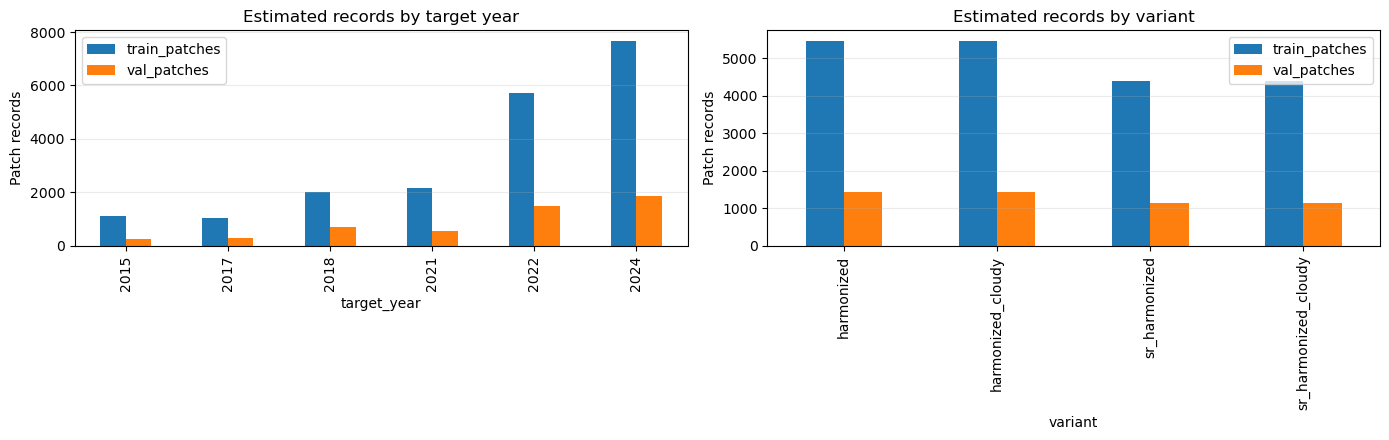

In [8]:
split_by_year = split_preview.groupby("target_year")[[
    "train_patches", "val_patches"
]].sum()
split_by_variant = split_preview.groupby("variant")[[
    "train_patches", "val_patches"
]].sum()

figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
split_by_year.plot.bar(ax=axes[0], title="Estimated records by target year")
split_by_variant.plot.bar(ax=axes[1], title="Estimated records by variant")
for axis in axes:
    axis.set_ylabel("Patch records")
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Direct patch extraction

Each source folder is opened once. Raster windows are read directly into a
`(channels, 4, 224, 224)` array. Missing frames remain zero. Edge windows are
zero-padded rather than stretched.

The target raster defines the common grid. Other years are wrapped in a
`WarpedVRT` only if their shape, CRS, or transform differs.

In [9]:
@contextmanager
def open_plan_sources(plan):
    with ExitStack() as stack:
        target = stack.enter_context(
            rasterio.open(plan.frame_paths[TARGET_INDEX])
        )
        sources = []
        for path in plan.frame_paths:
            if path is None:
                sources.append(None)
                continue
            source = stack.enter_context(rasterio.open(path))
            if not same_grid(source, target):
                source = stack.enter_context(
                    WarpedVRT(
                        source,
                        crs=target.crs,
                        transform=target.transform,
                        width=target.width,
                        height=target.height,
                        resampling=Resampling.bilinear,
                    )
                )
            sources.append(source)

        mask_source = stack.enter_context(rasterio.open(plan.mask_path))
        if (mask_source.height, mask_source.width) != (
            target.height,
            target.width,
        ):
            raise ValueError(
                f"Mask grid mismatch for {plan.target_group}: "
                f"{(mask_source.height, mask_source.width)} vs "
                f"{(target.height, target.width)}"
            )
        yield target, sources, mask_source


def read_padded_frame(source, window):
    output = np.zeros(
        (len(BAND_INDEXES), PATCH_SIZE, PATCH_SIZE), dtype=np.float32
    )
    if source is None:
        return output, False

    height = int(window.height)
    width = int(window.width)
    frame = source.read(
        indexes=BAND_INDEXES,
        window=window,
        out_dtype="float32",
        masked=True,
    )
    data = np.nan_to_num(frame.filled(0.0), nan=0.0, posinf=0.0, neginf=0.0)
    output[:, :height, :width] = data
    valid = bool(np.any(np.abs(data) > 0))
    return output, valid


def remap_mask(mask):
    output = np.zeros(mask.shape, dtype=np.uint8)
    known = np.zeros(mask.shape, dtype=bool)
    for source_class, target_class in CLASS_REMAP.items():
        selected = mask == source_class
        output[selected] = target_class
        known |= selected
    if not known.all():
        unknown = np.unique(mask[~known]).tolist()
        raise ValueError(f"Unknown mask classes: {unknown}")
    return output


def read_padded_mask(mask_source, window):
    output = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
    height = int(window.height)
    width = int(window.width)
    mask = mask_source.read(1, window=window)
    mask = remap_mask(np.asarray(mask))
    output[:height, :width] = mask
    return output


def make_patch_id(plan, row, col):
    text = (
        f"{plan.target_group}|{plan.variant}|{int(row)}|{int(col)}"
    )
    return hashlib.sha1(text.encode()).hexdigest()


def extract_patch(plan, target, sources, mask_source, window):
    image = np.zeros(
        (len(BAND_INDEXES), TIMESTEPS, PATCH_SIZE, PATCH_SIZE),
        dtype=np.float32,
    )
    temporal_mask = np.zeros(TIMESTEPS, dtype=np.float32)

    for timestep, source in enumerate(sources):
        frame, valid = read_padded_frame(source, window)
        image[:, timestep] = frame
        temporal_mask[timestep] = float(valid)

    mask = read_padded_mask(mask_source, window)
    latitude, longitude = patch_center(target.transform, window)
    split, spatial_block = split_for_location(latitude, longitude)
    frame_years = np.array(
        [year or 0 for year in plan.frame_years], dtype=np.int64
    )
    temporal_coords = np.stack(
        [
            frame_years,
            np.where(frame_years > 0, DAY_OF_YEAR, 0),
        ],
        axis=1,
    ).astype(np.float32)

    foreground_pixel_count = int(np.count_nonzero(mask))
    row = int(window.row_off)
    col = int(window.col_off)
    return {
        "image": np.ascontiguousarray(image),
        "mask": np.ascontiguousarray(mask),
        "temporal_coords": temporal_coords,
        "temporal_mask": temporal_mask,
        "location_coords": np.array(
            [latitude, longitude], dtype=np.float32
        ),
        "target_index": TARGET_INDEX,
        "target_year": plan.target_year,
        "sequence_version": plan.variant,
        "background_only": int(foreground_pixel_count == 0),
        "foreground_pixel_count": foreground_pixel_count,
        "valid_frame_count": int(temporal_mask.sum()),
        "frame_years": frame_years,
        "target_group": plan.target_group,
        "patch_id": make_patch_id(plan, row, col),
        "patch_row": row,
        "patch_col": col,
        "spatial_block": f"{spatial_block[0]}:{spatial_block[1]}",
        "split": split,
    }

## Inspect random source patches before exporting

A deterministic foreground patch is retained for the schema round-trip check.
The visualization cell then calls `visualize_patch_record()` with no record,
which draws fresh random patches on every execution. Set `split="train"` or
`split="val"`, and `foreground=True` or `False`, to filter the draw. Pass an
integer `seed` when a reproducible sample is needed. Missing slots are shown as
black and labeled `MASKED`.

In [10]:
def select_preview_plan(plans):
    matches = [
        plan
        for plan in plans
        if plan.target_year == PREVIEW_TARGET_YEAR
        and plan.variant == PREVIEW_VARIANT
    ]
    if matches:
        return matches[0]
    print("Requested preview group not found; using the first plan.")
    return plans[0]


def find_preview_patch(plan, require_foreground=True):
    with open_plan_sources(plan) as (target, sources, mask_source):
        first = None
        for window in iter_patch_windows(target.width, target.height):
            record = extract_patch(
                plan, target, sources, mask_source, window
            )
            if first is None:
                first = record
            if not require_foreground or not record["background_only"]:
                return record
    return first


preview_plan = select_preview_plan(plans)
preview_record = find_preview_patch(
    preview_plan, require_foreground=PREVIEW_FOREGROUND
)

print("Target group:", preview_record["target_group"])
print("Version:", preview_record["sequence_version"])
print("Split:", preview_record["split"])
print("Image shape:", preview_record["image"].shape)
print("Mask shape:", preview_record["mask"].shape)
print("Frame years:", preview_record["frame_years"].tolist())
print("Temporal mask:", preview_record["temporal_mask"].tolist())
print("Target index/year:", preview_record["target_index"], preview_record["target_year"])
print("Location [lat, lon]:", preview_record["location_coords"].tolist())
print("Background only:", bool(preview_record["background_only"]))
print("Mask classes:", np.unique(preview_record["mask"]).tolist())

c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Target group: sentinel_2021-0000023552-0000023552
Version: harmonized
Split: val
Image shape: (6, 4, 224, 224)
Mask shape: (224, 224)
Frame years: [2019, 2020, 2021, 2022]
Temporal mask: [1.0, 1.0, 1.0, 1.0]
Target index/year: 2 2021
Location [lat, lon]: [6.4481072425842285, -2.0416910648345947]
Background only: False
Mask classes: [0, 1, 2]


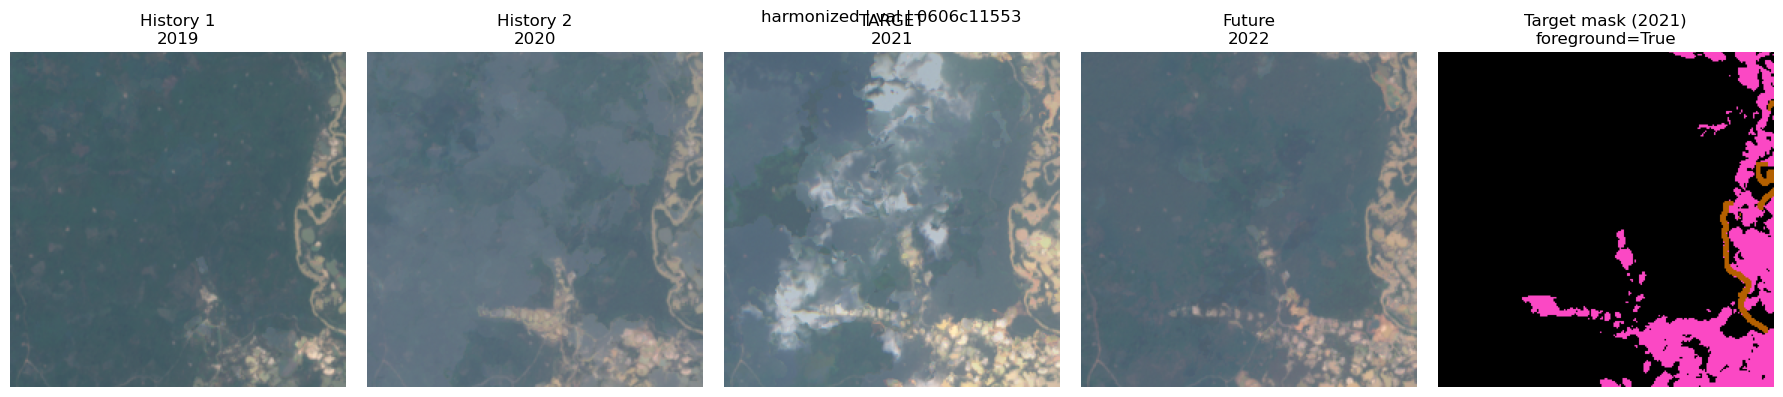

In [13]:
CLASS_COLORS = {
    0: [0, 0, 0],
    1: [251, 72, 196],
    2: [180, 96, 0],
}


def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb


def frame_to_rgb(frame, divisor=3000.0):
    rgb = frame[[2, 1, 0]].transpose(1, 2, 0)
    return np.clip(rgb / divisor, 0.0, 1.0)


def sample_random_patch_records(
    plans,
    sample_count=RANDOM_PREVIEW_SAMPLES,
    split=None,
    foreground=None,
    seed=RANDOM_PREVIEW_SEED,
):
    """Sample source patches without materializing every image tensor."""
    if sample_count < 1:
        raise ValueError("sample_count must be at least 1")
    if split not in (None, "train", "val"):
        raise ValueError("split must be None, 'train', or 'val'")

    candidates = []
    for plan_index, plan in enumerate(plans):
        with rasterio.open(plan.frame_paths[TARGET_INDEX]) as target:
            for window in iter_patch_windows(target.width, target.height):
                latitude, longitude = patch_center(
                    target.transform, window
                )
                patch_split, _ = split_for_location(
                    latitude, longitude
                )
                if split is None or patch_split == split:
                    candidates.append((plan_index, window))

    if not candidates:
        raise ValueError("No patches match the requested split")

    rng = np.random.default_rng(seed)
    selected = []
    for candidate_index in rng.permutation(len(candidates)):
        plan_index, window = candidates[int(candidate_index)]
        plan = plans[plan_index]
        with open_plan_sources(plan) as (target, sources, mask_source):
            record = extract_patch(
                plan, target, sources, mask_source, window
            )
        has_foreground = not bool(record["background_only"])
        if foreground is not None and has_foreground != foreground:
            continue
        selected.append(record)
        if len(selected) == sample_count:
            break

    if len(selected) < sample_count:
        print(
            f"Only {len(selected)} patches matched the requested filters."
        )
    return selected


def visualize_patch_record(
    record=None,
    *,
    sample_count=RANDOM_PREVIEW_SAMPLES,
    split=None,
    foreground=None,
    seed=RANDOM_PREVIEW_SEED,
):
    """Visualize supplied records, or fresh random source patches by default."""
    random_selection = record is None
    if random_selection:
        records = sample_random_patch_records(
            plans,
            sample_count=sample_count,
            split=split,
            foreground=foreground,
            seed=seed,
        )
    elif isinstance(record, dict):
        records = [record]
    else:
        records = list(record)

    if not records:
        raise ValueError("No records were supplied or sampled")

    roles = ["History 1", "History 2", "TARGET", "Future"]
    figure, axes = plt.subplots(
        len(records),
        5,
        figsize=(18, 4 * len(records)),
        squeeze=False,
    )

    for row, current in enumerate(records):
        for timestep in range(TIMESTEPS):
            valid = bool(current["temporal_mask"][timestep])
            rgb = frame_to_rgb(current["image"][:, timestep])
            axes[row, timestep].imshow(rgb)
            year = int(current["frame_years"][timestep])
            status = str(year) if valid else "MASKED"
            axes[row, timestep].set_title(
                f"{roles[timestep]}\n{status}"
            )
            axes[row, timestep].axis("off")

        axes[row, -1].imshow(mask_to_rgb(current["mask"]))
        axes[row, -1].set_title(
            f"Target mask ({current['target_year']})\n"
            f"foreground={not bool(current['background_only'])}"
        )
        axes[row, -1].axis("off")
        axes[row, 0].text(
            -0.04,
            0.5,
            f"Sample {row + 1}\n{current['sequence_version']}\n"
            f"{current['split']} | {current['patch_id'][:10]}",
            transform=axes[row, 0].transAxes,
            ha="right",
            va="center",
            rotation=90,
            fontsize=9,
        )
        print(
            f"Sample {row + 1}: {current['sequence_version']} | "
            f"{current['split']} | target={current['target_year']} | "
            f"background_only={bool(current['background_only'])} | "
            f"patch_id={current['patch_id']}"
        )

    title = (
        "Random patch samples — rerun for a new draw"
        if random_selection and seed is None
        else "Patch samples"
    )
    figure.suptitle(title)
    plt.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()
    return records


random_preview_records = visualize_patch_record()

## TFRecord schema

Core tensors remain compatible with `MineFootprintTFRecordDataset`. Extra
features make the target and provenance explicit.

| Feature | Stored value |
|---|---|
| `image_raw` | float32 `(6, 4, 224, 224)` |
| `mask_raw` | uint8 `(224, 224)` |
| `temporal_coords` | float32 `(4, 2)` |
| `temporal_mask` | float32 `(4,)` |
| `location_coords` | float32 `[lat, lon]` |
| `target_index` | always `2` |
| `target_year` | year encoded by source folder/mask |
| `sequence_version` | harmonized/cloudy/SR variant |
| `background_only` | `1` when the patch mask has no foreground |
| `foreground_pixel_count` | number of nonzero target-mask pixels |
| `frame_years` | integer years, zero for missing frames |
| `spatial_block` | deterministic geographic split group |
| `patch_id` | stable source/version/window identifier |

In [14]:
def bytes_feature(value):
    if isinstance(value, str):
        value = value.encode("utf-8")
    if isinstance(value, np.ndarray):
        value = np.ascontiguousarray(value).tobytes()
    return tf.train.Feature(
        bytes_list=tf.train.BytesList(value=[value])
    )


def int64_feature(value):
    if isinstance(value, np.ndarray):
        value = value.reshape(-1).tolist()
    elif not isinstance(value, (list, tuple)):
        value = [value]
    return tf.train.Feature(
        int64_list=tf.train.Int64List(value=[int(item) for item in value])
    )


def float_feature(value):
    if isinstance(value, np.ndarray):
        value = value.reshape(-1).tolist()
    elif not isinstance(value, (list, tuple)):
        value = [value]
    return tf.train.Feature(
        float_list=tf.train.FloatList(
            value=[float(item) for item in value]
        )
    )


def serialize_patch(record):
    image = np.asarray(record["image"], dtype=np.float32)
    mask = np.asarray(record["mask"], dtype=np.uint8)
    channels, timesteps, height, width = image.shape
    if (timesteps, height, width) != (
        TIMESTEPS,
        PATCH_SIZE,
        PATCH_SIZE,
    ):
        raise ValueError(f"Unexpected image shape: {image.shape}")
    if mask.shape != (PATCH_SIZE, PATCH_SIZE):
        raise ValueError(f"Unexpected mask shape: {mask.shape}")
    if int(record["target_index"]) != TARGET_INDEX:
        raise ValueError("Target index changed during serialization")

    features = {
        "image_raw": bytes_feature(image),
        "mask_raw": bytes_feature(mask),
        "height": int64_feature(height),
        "width": int64_feature(width),
        "channels": int64_feature(channels),
        "timesteps": int64_feature(timesteps),
        "temporal_coords": float_feature(record["temporal_coords"]),
        "temporal_mask": float_feature(record["temporal_mask"]),
        "location_coords": float_feature(record["location_coords"]),
        "target_index": int64_feature(record["target_index"]),
        "target_year": int64_feature(record["target_year"]),
        "sequence_version": bytes_feature(record["sequence_version"]),
        "background_only": int64_feature(record["background_only"]),
        "foreground_pixel_count": int64_feature(
            record["foreground_pixel_count"]
        ),
        "valid_frame_count": int64_feature(record["valid_frame_count"]),
        "frame_years": int64_feature(record["frame_years"]),
        "target_group": bytes_feature(record["target_group"]),
        "patch_id": bytes_feature(record["patch_id"]),
        "patch_row": int64_feature(record["patch_row"]),
        "patch_col": int64_feature(record["patch_col"]),
        "spatial_block": bytes_feature(record["spatial_block"]),
        "split": bytes_feature(record["split"]),
        "schema_version": bytes_feature(SCHEMA_VERSION),
    }
    example = tf.train.Example(
        features=tf.train.Features(feature=features)
    )
    return example.SerializeToString()


# Round-trip the preview record before any large export.
preview_serialized = serialize_patch(preview_record)
print("Preview serialized bytes:", len(preview_serialized))
preview_example = tf.train.Example.FromString(preview_serialized)
print("Serialized feature keys:")
print(sorted(preview_example.features.feature))

Preview serialized bytes: 4867783
Serialized feature keys:
['background_only', 'channels', 'foreground_pixel_count', 'frame_years', 'height', 'image_raw', 'location_coords', 'mask_raw', 'patch_col', 'patch_id', 'patch_row', 'schema_version', 'sequence_version', 'spatial_block', 'split', 'target_group', 'target_index', 'target_year', 'temporal_coords', 'temporal_mask', 'timesteps', 'valid_frame_count', 'width']


## Streaming export

Two writers stay open while source folders are processed. Every patch is
assigned by spatial block and written immediately; no patch arrays are retained
after serialization.

Outputs are first written with a `.partial` suffix and atomically renamed only
after successful completion. This prevents an interrupted run from looking like
a finished TFRecord.

In [15]:
def new_export_stats():
    return {
        "records": Counter(),
        "background": Counter(),
        "foreground": Counter(),
        "by_target_year": Counter(),
        "by_variant": Counter(),
        "by_valid_frame_pattern": Counter(),
        "skipped_invalid_target": 0,
        "train_blocks": set(),
        "val_blocks": set(),
        "started_at": time.time(),
    }


def update_export_stats(stats, record):
    split = record["split"]
    stats["records"][split] += 1
    key = (split, int(record["target_year"]))
    stats["by_target_year"][key] += 1
    stats["by_variant"][(split, record["sequence_version"])] += 1
    pattern = "".join(
        str(int(value)) for value in record["temporal_mask"]
    )
    stats["by_valid_frame_pattern"][(split, pattern)] += 1
    if record["background_only"]:
        stats["background"][split] += 1
    else:
        stats["foreground"][split] += 1
    block = record["spatial_block"]
    stats[f"{split}_blocks"].add(block)


def printable_summary(stats):
    elapsed = time.time() - stats["started_at"]
    train_blocks = stats["train_blocks"]
    val_blocks = stats["val_blocks"]
    return {
        "schema_version": SCHEMA_VERSION,
        "train_tfrecord": str(TRAIN_TFRECORD),
        "val_tfrecord": str(VAL_TFRECORD),
        "elapsed_seconds": elapsed,
        "records": dict(stats["records"]),
        "background": dict(stats["background"]),
        "foreground": dict(stats["foreground"]),
        "by_target_year": {
            f"{split}|{year}": count
            for (split, year), count in stats["by_target_year"].items()
        },
        "by_variant": {
            f"{split}|{variant}": count
            for (split, variant), count in stats["by_variant"].items()
        },
        "by_valid_frame_pattern": {
            f"{split}|{pattern}": count
            for (split, pattern), count in stats[
                "by_valid_frame_pattern"
            ].items()
        },
        "skipped_invalid_target": stats["skipped_invalid_target"],
        "train_spatial_blocks": len(train_blocks),
        "val_spatial_blocks": len(val_blocks),
        "spatial_block_overlap": len(train_blocks & val_blocks),
        "configuration": {
            "patch_size": PATCH_SIZE,
            "stride": STRIDE,
            "target_index": TARGET_INDEX,
            "val_fraction": VAL_FRACTION,
            "split_seed": SPLIT_SEED,
            "spatial_block_degrees": SPATIAL_BLOCK_DEGREES,
            "max_groups": MAX_GROUPS,
            "max_patches_per_group": MAX_PATCHES_PER_GROUP,
        },
    }


def protect_output(path):
    if path.exists() and not OVERWRITE_OUTPUTS:
        raise FileExistsError(
            f"Output exists: {path}. Set OVERWRITE_OUTPUTS=True to replace it."
        )


def export_tfrecords(plans):
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    for path in (TRAIN_TFRECORD, VAL_TFRECORD, SUMMARY_JSON):
        protect_output(path)

    train_partial = TRAIN_TFRECORD.with_suffix(
        TRAIN_TFRECORD.suffix + ".partial"
    )
    val_partial = VAL_TFRECORD.with_suffix(
        VAL_TFRECORD.suffix + ".partial"
    )
    for path in (train_partial, val_partial):
        if path.exists():
            raise FileExistsError(
                f"Partial output already exists: {path}. Inspect or remove it first."
            )

    stats = new_export_stats()
    selected_plans = plans[:MAX_GROUPS] if MAX_GROUPS else plans
    processed = 0

    with tf.io.TFRecordWriter(str(train_partial)) as train_writer, \
         tf.io.TFRecordWriter(str(val_partial)) as val_writer:
        for plan_number, plan in enumerate(selected_plans, start=1):
            print(
                f"\n[{plan_number}/{len(selected_plans)}] "
                f"{plan.target_group} | {plan.variant} | "
                f"years={plan.frame_years}"
            )
            written_for_plan = 0
            with open_plan_sources(plan) as (
                target,
                sources,
                mask_source,
            ):
                for window in iter_patch_windows(
                    target.width, target.height
                ):
                    if (
                        MAX_PATCHES_PER_GROUP is not None
                        and written_for_plan >= MAX_PATCHES_PER_GROUP
                    ):
                        break

                    record = extract_patch(
                        plan, target, sources, mask_source, window
                    )
                    if (
                        SKIP_INVALID_TARGET_PATCHES
                        and not record["temporal_mask"][TARGET_INDEX]
                    ):
                        stats["skipped_invalid_target"] += 1
                        continue

                    serialized = serialize_patch(record)
                    if record["split"] == "val":
                        val_writer.write(serialized)
                    else:
                        train_writer.write(serialized)
                    update_export_stats(stats, record)
                    written_for_plan += 1
                    processed += 1

                    if processed % PROGRESS_EVERY == 0:
                        elapsed = time.time() - stats["started_at"]
                        rate = processed / max(elapsed, 1e-9)
                        print(
                            f"  records={processed:,} | "
                            f"train={stats['records']['train']:,} | "
                            f"val={stats['records']['val']:,} | "
                            f"{rate:.1f} records/s"
                        )

            print(f"  wrote {written_for_plan:,} records")

    train_blocks = stats["train_blocks"]
    val_blocks = stats["val_blocks"]
    if not train_blocks.isdisjoint(val_blocks):
        raise RuntimeError("Spatial block leakage detected before finalization")

    os.replace(train_partial, TRAIN_TFRECORD)
    os.replace(val_partial, VAL_TFRECORD)
    summary = printable_summary(stats)
    SUMMARY_JSON.write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )
    print("\nExport complete")
    print(json.dumps(summary, indent=2))
    return summary

In [16]:
estimated = split_preview[[
    "train_patches", "val_patches", "total_patches"
]].sum()
estimated_bytes = int(estimated["total_patches"]) * len(preview_serialized)

print("Estimated unfiltered records:", int(estimated["total_patches"]))
print("Estimated serialized size: {:.1f} GB".format(estimated_bytes / 1e9))
print("Train path:", TRAIN_TFRECORD)
print("Validation path:", VAL_TFRECORD)
print("\nSet RUN_EXPORT=True in the configuration cell when ready.")

Estimated unfiltered records: 24860
Estimated serialized size: 121.0 GB
Train path: D:\Data\ssm_temporal\ssm_footprint_train_clean.tfrecord
Validation path: D:\Data\ssm_temporal\ssm_footprint_val_clean.tfrecord

Set RUN_EXPORT=True in the configuration cell when ready.


In [17]:
RUN_EXPORT = True  # Set to True to run the export.

In [18]:
if RUN_EXPORT:
    export_summary = export_tfrecords(plans)
else:
    export_summary = None
    print("Export skipped because RUN_EXPORT=False.")


[1/24] sentinel_2015-0000011776-0000023552 | harmonized | years=(None, None, 2015, 2016)


c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


  records=500 | train=390 | val=110 | 12.3 records/s
  wrote 676 records

[2/24] sentinel_2015-0000011776-0000023552 | harmonized_cloudy | years=(None, None, 2015, 2016)
  records=1,000 | train=802 | val=198 | 12.5 records/s
  wrote 676 records

[3/24] sentinel_2017-0000035328-0000023552 | harmonized | years=(2015, 2016, 2017, 2018)
  records=1,500 | train=1,230 | val=270 | 11.5 records/s
  records=2,000 | train=1,607 | val=393 | 10.1 records/s
  wrote 676 records

[4/24] sentinel_2017-0000035328-0000023552 | harmonized_cloudy | years=(2015, 2016, 2017, 2018)
  records=2,500 | train=1,998 | val=502 | 9.0 records/s
  wrote 676 records

[5/24] sentinel_2018-0000047104-0000035328 | harmonized | years=(2016, 2017, 2018, 2019)
  records=3,000 | train=2,361 | val=639 | 8.5 records/s
  wrote 676 records

[6/24] sentinel_2018-0000047104-0000035328 | harmonized_cloudy | years=(2016, 2017, 2018, 2019)
  records=3,500 | train=2,724 | val=776 | 8.2 records/s
  records=4,000 | train=3,111 | val=889

## Post-export verification

The checks below index TFRecord framing without decoding every large tensor,
read uniform random records directly by byte offset, confirm target index/year
consistency, and verify that train and validation spatial-block identifiers do
not overlap. With `RANDOM_PREVIEW_SEED=None`, rerunning the cells gives a new
draw.

In [19]:
CLEAN_FEATURE_DESCRIPTION = {
    "image_raw": tf.io.FixedLenFeature([], tf.string),
    "mask_raw": tf.io.FixedLenFeature([], tf.string),
    "height": tf.io.FixedLenFeature([], tf.int64),
    "width": tf.io.FixedLenFeature([], tf.int64),
    "channels": tf.io.FixedLenFeature([], tf.int64),
    "timesteps": tf.io.FixedLenFeature([], tf.int64),
    "temporal_coords": tf.io.FixedLenFeature([TIMESTEPS * 2], tf.float32),
    "temporal_mask": tf.io.FixedLenFeature([TIMESTEPS], tf.float32),
    "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    "target_index": tf.io.FixedLenFeature([], tf.int64),
    "target_year": tf.io.FixedLenFeature([], tf.int64),
    "sequence_version": tf.io.FixedLenFeature([], tf.string),
    "background_only": tf.io.FixedLenFeature([], tf.int64),
    "foreground_pixel_count": tf.io.FixedLenFeature([], tf.int64),
    "valid_frame_count": tf.io.FixedLenFeature([], tf.int64),
    "frame_years": tf.io.FixedLenFeature([TIMESTEPS], tf.int64),
    "target_group": tf.io.FixedLenFeature([], tf.string),
    "patch_id": tf.io.FixedLenFeature([], tf.string),
    "patch_row": tf.io.FixedLenFeature([], tf.int64),
    "patch_col": tf.io.FixedLenFeature([], tf.int64),
    "spatial_block": tf.io.FixedLenFeature([], tf.string),
    "split": tf.io.FixedLenFeature([], tf.string),
    "schema_version": tf.io.FixedLenFeature([], tf.string),
}


def decode_serialized_example(serialized):
    example = tf.io.parse_single_example(
        serialized, CLEAN_FEATURE_DESCRIPTION
    )
    channels = int(example["channels"])
    timesteps = int(example["timesteps"])
    height = int(example["height"])
    width = int(example["width"])
    image = np.frombuffer(
        example["image_raw"].numpy(), dtype=np.float32
    ).reshape(channels, timesteps, height, width)
    mask = np.frombuffer(
        example["mask_raw"].numpy(), dtype=np.uint8
    ).reshape(height, width)
    return {
        "image": image,
        "mask": mask,
        "temporal_coords": example["temporal_coords"].numpy().reshape(
            timesteps, 2
        ),
        "temporal_mask": example["temporal_mask"].numpy(),
        "location_coords": example["location_coords"].numpy(),
        "target_index": int(example["target_index"]),
        "target_year": int(example["target_year"]),
        "sequence_version": example["sequence_version"].numpy().decode(),
        "background_only": int(example["background_only"]),
        "foreground_pixel_count": int(
            example["foreground_pixel_count"]
        ),
        "valid_frame_count": int(example["valid_frame_count"]),
        "frame_years": example["frame_years"].numpy(),
        "target_group": example["target_group"].numpy().decode(),
        "patch_id": example["patch_id"].numpy().decode(),
        "patch_row": int(example["patch_row"]),
        "patch_col": int(example["patch_col"]),
        "spatial_block": example["spatial_block"].numpy().decode(),
        "split": example["split"].numpy().decode(),
        "schema_version": example["schema_version"].numpy().decode(),
    }


def index_tfrecord_frames(path):
    frame_index = []
    position = 0
    size = path.stat().st_size
    with path.open("rb") as stream:
        while position < size:
            stream.seek(position)
            header = stream.read(12)
            if not header:
                break
            if len(header) != 12:
                raise RuntimeError(
                    f"Incomplete TFRecord header at byte {position:,}"
                )
            record_length = struct.unpack("<Q", header[:8])[0]
            data_offset = position + 12
            frame_index.append((data_offset, record_length))
            position = data_offset + record_length + 4
    if position != size:
        raise RuntimeError(
            f"TFRecord framing ended at {position:,}, file has {size:,} bytes"
        )
    return frame_index


def count_tfrecord_frames(path):
    return len(index_tfrecord_frames(path))


def read_random_tfrecord_records(
    path,
    sample_count=1,
    seed=RANDOM_PREVIEW_SEED,
    frame_index=None,
):
    """Read uniform random TFRecord samples using direct byte offsets."""
    if sample_count < 1:
        raise ValueError("sample_count must be at least 1")
    if frame_index is None:
        frame_index = index_tfrecord_frames(path)
    if not frame_index:
        raise ValueError(f"TFRecord file is empty: {path}")

    selected_count = min(sample_count, len(frame_index))
    rng = np.random.default_rng(seed)
    selected_indices = np.atleast_1d(
        rng.choice(
            len(frame_index), size=selected_count, replace=False
        )
    ).astype(int).tolist()

    records = []
    with path.open("rb") as stream:
        for record_index in selected_indices:
            data_offset, record_length = frame_index[record_index]
            stream.seek(data_offset)
            serialized = stream.read(record_length)
            if len(serialized) != record_length:
                raise RuntimeError(
                    f"Incomplete record {record_index} in {path}"
                )
            records.append(
                decode_serialized_example(
                    tf.convert_to_tensor(serialized, dtype=tf.string)
                )
            )
    return records, selected_indices


def validate_decoded_record(record, expected_split=None):
    assert record["image"].shape == (
        len(BAND_INDEXES), TIMESTEPS, PATCH_SIZE, PATCH_SIZE
    )
    assert record["mask"].shape == (PATCH_SIZE, PATCH_SIZE)
    assert record["target_index"] == TARGET_INDEX
    assert record["frame_years"][TARGET_INDEX] == record["target_year"]
    assert record["temporal_mask"][TARGET_INDEX] == 1
    assert set(np.unique(record["mask"])).issubset({0, 1, 2})
    assert record["background_only"] == int(
        not np.any(record["mask"] > 0)
    )
    if expected_split is not None:
        assert record["split"] == expected_split
    return True


validate_decoded_record(decode_serialized_example(preview_serialized))
print("Preview round-trip validation passed.")

Preview round-trip validation passed.


In [20]:
if RUN_EXPORT and TRAIN_TFRECORD.exists() and VAL_TFRECORD.exists():
    train_frame_index = index_tfrecord_frames(TRAIN_TFRECORD)
    val_frame_index = index_tfrecord_frames(VAL_TFRECORD)
    train_count = len(train_frame_index)
    val_count = len(val_frame_index)
    print("Train records:", train_count)
    print("Validation records:", val_count)

    train_examples, train_sample_indices = read_random_tfrecord_records(
        TRAIN_TFRECORD,
        sample_count=RANDOM_TFRECORD_SAMPLES_PER_SPLIT,
        seed=RANDOM_PREVIEW_SEED,
        frame_index=train_frame_index,
    )
    val_examples, val_sample_indices = read_random_tfrecord_records(
        VAL_TFRECORD,
        sample_count=RANDOM_TFRECORD_SAMPLES_PER_SPLIT,
        seed=RANDOM_PREVIEW_SEED,
        frame_index=val_frame_index,
    )
    for record in train_examples:
        validate_decoded_record(record, "train")
    for record in val_examples:
        validate_decoded_record(record, "val")
    print("Random train indices:", train_sample_indices)
    print("Random validation indices:", val_sample_indices)
    print("Random train and validation records passed.")
else:
    train_frame_index = []
    val_frame_index = []
    train_examples = []
    val_examples = []
    train_sample_indices = []
    val_sample_indices = []
    print("Run the export before post-export file validation.")

Train records: 19716
Validation records: 5144
Representative train and validation records passed.


In [26]:
if train_examples:
    print("Random training examples")
    visualize_patch_record(train_examples)
if val_examples:
    print("Random validation examples")
    visualize_patch_record(val_examples)

NameError: name 'train_examples' is not defined

## Training-loader update

Existing loaders that request only the old features can still parse these
records because TensorFlow ignores additional Example features. To use the new
target semantics, update `MineFootprintTFRecordDataset.FEATURE_DESCRIPTION` to
include at least:

```python
"temporal_mask": tf.io.FixedLenFeature([4], tf.float32),
"target_index": tf.io.FixedLenFeature([], tf.int64),
"target_year": tf.io.FixedLenFeature([], tf.int64),
"sequence_version": tf.io.FixedLenFeature([], tf.string),
"background_only": tf.io.FixedLenFeature([], tf.int64),
```

The decoder should use the patch features associated with `target_index=2`, or
receive an explicit target indicator. Do not infer the target from the last
valid temporal coordinate: the fourth frame is intentionally future context.

## Final checklist

- Inspect the inventory and ignored-file warning.
- Confirm all source-audit issues are resolved.
- Inspect split counts by target year and variant.
- Inspect the four-frame preview and target mask.
- Confirm output paths and estimated size.
- Set `RUN_EXPORT=True` and run the export cell.
- Verify record counts and decoded examples.
- Keep the generated summary JSON with the TFRecords.
- Update the training loader to consume `target_index` and `target_year`.

The split seed, spatial-block size, and schema version are stored in the summary
so the dataset can be reproduced and audited later.